# 02_iris_quickstart — Iris 첫 모델 & 모델 교체

목표
- 데이터를 학습/시험용으로 나누는 이유를 이해
- 첫 모델(DecisionTree)로 학습 → 예측 → 정확도를 계산
- 같은 절차로 LogisticRegression, KNN으로 교체
- 간단한 파라미터 변경으로 성능 차이를 직접 확인

In [8]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
import sklearn, numpy as np, pandas as pd
import matplotlib, seaborn

print(f'sklearn: {sklearn.__version__}')
print(f'numpy: {np.__version__}')
print(f'pandas: {pd.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn: {seaborn.__version__}')

sklearn: 1.6.1
numpy: 2.3.3
pandas: 2.3.2
matplotlib: 3.10.6
seaborn: 0.13.2


---
## Part 1. 첫 번째 모델 맛보기

> 모델 코드는 **3줄**이면 충분!
> `fit(학습) → predict(예측) → score(평가)`

### 왜 Iris 데이터일까?
- 꽃받침(sepal), 꽃잎(petal)의 길이·너비 **4개의 수치만** 보고도 품종을 맞출 수 있을까?
- 마치 '신발 사이즈와 키'만 보고도 남/녀를 구별하는 느낌과 비슷함
- 머신러닝 교재에서 Hello World로 쓰이는 이유:
  - 데이터가 작고 단순하다 (150개 샘플, 3개 클래스)

In [3]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [13]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [13]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [19]:
import pandas as pd

iris = load_iris()
iris
iris_data = iris.data
iris_data

iris_label = iris.target
iris_label
print('iris target값:', iris_label)
print('iris target명:', iris.target_names)

iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df.head(3)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


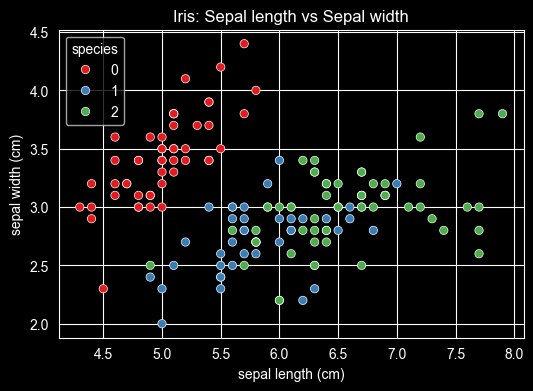

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df["species"] = y

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=iris_df,
    x="sepal length (cm)", y="sepal width (cm)",
    hue="species", palette="Set1"
)
plt.title("Iris: Sepal length vs Sepal width")
plt.show()

## Train/Test 분리
같은 데이터로 공부하고 시험 보면 성적이 부풀어진다.
처음 보는 데이터(Test)로 성능을 확인해야 한다.

In [20]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (120, 4) (120,)
Test : (30, 4) (30,)


## 첫 모델: DecisionTree 분류기
scikit-learn 모델은 모두 같은 패턴으로 쓴다.
- fit(학습), predict(예측), 평가(점수/지표)

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. 모델 생성
dt = DecisionTreeClassifier(random_state=18)

# 2. 학습 (fit) — 모델이 데이터의 패턴을 학습
dt.fit(X_train, y_train)

# 3. 예측 (predict) — 처음 보는 테스트 데이터로 예측
pred = dt.predict(X_test)

# 4. 평가 (score) — 정확도 계산
acc = accuracy_score(y_test, pred)
print(f"DecisionTree 정확도: {acc:.3f}")

DecisionTree 정확도: 0.967


## 정확도(Accuracy) 해석
정확도 = (맞춘 개수) / (전체 개수)
직관적이지만, 데이터가 불균형하면 착시가 생길 수 있음

### 모델 바꿔보기 — sklearn의 힘

> 모델만 바꿔 끼우면 됩니다. `fit → predict → score` 패턴은 **동일**!

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

results = []

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
results.append(("DecisionTree", accuracy_score(y_test, dt.predict(X_test))))

# Logistic Regression — 확률 기반 분류
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)
results.append(("LogisticRegression", accuracy_score(y_test, lr.predict(X_test))))

# KNN (K-Nearest Neighbors) — 가장 가까운 이웃 k개를 보고 다수결
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
results.append(("KNN (k=5)", accuracy_score(y_test, knn.predict(X_test))))

# 결과 비교 표
pd.DataFrame(results, columns=["모델", "정확도"]).sort_values("정확도", ascending=False)

,모델,정확도
2,KNN (k=5),1.000000
1,LogisticRegression,0.966667
0,DecisionTree,0.933333


In [ ]:
# 1. 모델 생성
dt = KNeighborsClassifier(n_neighbors=5)

# 2. 학습 (fit) — 모델이 데이터의 패턴을 학습
dt.fit(X_train, y_train)

# 3. 예측 (predict) — 처음 보는 테스트 데이터로 예측
pred = dt.predict(X_test)

# 4. 평가 (score) — 정확도 계산
acc = accuracy_score(y_test, pred)
print(f"DecisionTree 정확도: {acc:.3f}")

> 모델 코드 **3줄**이 전부임
> 다만 **돌리기는 쉽지만, 성능을 올리는 것은 어려움.**
> 그래서 EDA, 전처리, 하이퍼파라미터 튜닝이 중요함.
> 모델을 이해해야 함

### (참고) random_state란?

> **"어떤 문제가 시험에 나올지 섞는 방식"**

`random_state`를 바꾸면 시험 문제가 바뀜

---

### 왜 항상 random_state를 넣을까?

**안 넣으면 생기는 문제:**

```python
train_test_split(X, y)  # random_state 없음
```

실행할 때마다 섞는 순서가 달라짐 → 결과가 매번 달라짐


In [ ]:
# 1.random_state 없이 나눴을 때 — 여러 번 실행해보세요!
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X, y, test_size=0.2
)

model_temp = DecisionTreeClassifier()
model_temp.fit(X_train_temp, y_train_temp)

acc_temp = accuracy_score(y_test_temp, model_temp.predict(X_test_temp))
print(f"Accuracy (no random_state): {acc_temp:.3f}")
print("→ 이 셀을 여러 번 실행하면 매번 accuracy가 달라짐!")

In [10]:
# 2.random_state를 고정했을 때 — 여러 번 실행해보세요!
X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_fixed = DecisionTreeClassifier(random_state=18)
model_fixed.fit(X_train_fixed, y_train_fixed)

acc_fixed = accuracy_score(y_test_fixed, model_fixed.predict(X_test_fixed))
print(f"Accuracy (random_state=42): {acc_fixed:.3f}")
print("→ 몇 번을 실행해도 항상 같은 결과!")

Accuracy (random_state=42): 1.000
→ 몇 번을 실행해도 항상 같은 결과!
